# Exercise 2

## Supervised Learning- Regression Models


---

## Overview

Welcome to this excercise. We are now going to use our new skills to build our supervised learning models that use an Elastict Net Regression.

---


In [1]:
import sys
import os

# Manually set the path relative to the py file's location that you want to import
func_lib_path = os.path.abspath(
    os.path.join(os.getcwd(), "./")
)  # Add the path to sys.path
sys.path.append(func_lib_path)

# Now you can import func_lib
import func_lib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from sklearn.linear_model import ElasticNet

In [2]:
# Retrieve historical price data.
# - Use the 'createHistPrices()' function from 'func_lib' to get historical price data.
# - Assign the result to the variable 'historical_prices'.

historical_prices = func_lib.create_hist_prices()

# Define the list of momentum periods.
# - Create a list containing different time periods for calculating momentum indicators.
# - Assign this list to the variable 'list_of_momentums'.

list_of_momentums = [1, 5, 15, 20]

# Compute returns based on historical prices and momentum periods.
# - Use the 'computingReturns()' function from 'func_lib' with 'historical_prices' and 'list_of_momentums' as inputs.
# - Assign the result to the variable 'total_returns'.

total_returns = func_lib.compute_returns(historical_prices, list_of_momentums)

# Remove any rows with missing values from the returns data.
# - Use the 'dropna()' method to remove rows with NaN values from 'total_returns'.
# - Apply the change in place to modify the DataFrame directly.

total_returns.dropna(inplace=True)

[**********************48%                       ]  240 of 501 completed$Q: possibly delisted; no price data found  (1d 2000-01-01 -> 2024-05-01) (Yahoo error = "Data doesn't exist for startDate = 946702800, endDate = 1714536000")
[**********************68%********               ]  341 of 501 completed$SNDK: possibly delisted; no price data found  (1d 2000-01-01 -> 2024-05-01) (Yahoo error = "Data doesn't exist for startDate = 946702800, endDate = 1714536000")
[*********************100%***********************]  501 of 501 completed

2 Failed downloads:
['Q', 'SNDK']: possibly delisted; no price data found  (1d 2000-01-01 -> 2024-05-01) (Yahoo error = "Data doesn't exist for startDate = 946702800, endDate = 1714536000")


In [3]:
# Determine the split index for 70% of the dates.
# - Extract the unique dates from the index of 'total_returns'.
# - Calculate the split date by indexing into the unique dates to get the date corresponding to 70% of the total length of unique dates.
# - Assign this date to the variable 'split_date' and display it.

unique_dates = total_returns.index.get_level_values("Date").unique()
split_date = unique_dates[int(0.7 * len(unique_dates))]
print(split_date)

2017-01-20 00:00:00


In [4]:
# Create the training set: all data before the split date.
# - Use the 'loc[]' indexer to select rows from 'total_returns' where the date in the index is earlier than 'split_date'.
# - Assign this subset of data to the variable 'train_data'.
train_data = total_returns.loc[
    total_returns.index.get_level_values("Date") < split_date
]
print(train_data.head())

# Create the testing set: all data from the split date onwards.
# - Use the 'loc[]' indexer to select rows from 'total_returns' where the date in the index is equal to or later than 'split_date'.
# - Assign this subset of data to the variable 'test_data'.
test_data = total_returns.loc[
    total_returns.index.get_level_values("Date") >= split_date
]
print(test_data.head())

                   F_1_d_returns  1_d_returns  5_d_returns  15_d_returns  \
Ticker Date                                                                
A      2000-02-01       0.077465     0.072710     0.048938      0.029919   
       2000-02-02       0.016340     0.077465     0.119853      0.125000   
       2000-02-03      -0.019293     0.016340     0.136073      0.166979   
       2000-02-04       0.042623    -0.019293     0.120294      0.127542   
       2000-02-07      -0.006289     0.042623     0.201133      0.162706   

                   20_d_returns  
Ticker Date                      
A      2000-02-01     -0.013889  
       2000-02-02      0.150376  
       2000-02-03      0.246493  
       2000-02-04      0.270833  
       2000-02-07      0.223077  
                   F_1_d_returns  1_d_returns  5_d_returns  15_d_returns  \
Ticker Date                                                                
A      2017-01-20      -0.004830    -0.000420    -0.018549      0.044573   
 

In [5]:
# Extract the target variable for testing.
# - Select the 'F_1_d_returns' column from the 'test_data' DataFrame.
# - Assign this column to the variable 'total_returns'.
total_returns = test_data["F_1_d_returns"]
total_returns.head()

Ticker  Date      
A       2017-01-20   -0.004830
        2017-01-23   -0.000844
        2017-01-24    0.022387
        2017-01-25   -0.004958
        2017-01-26    0.009965
Name: F_1_d_returns, dtype: float64

In [6]:
# Define the feature and target columns.
# - List the names of the feature columns in 'features'.
# - List the name of the target column in 'target'.
features = ["1_d_returns", "5_d_returns", "15_d_returns", "20_d_returns"]
target = ["F_1_d_returns"]

# Split the data into training and testing sets.
# - Extract the feature columns from 'train_data' and 'test_data' to create 'X_train' and 'X_test'.
# - Extract the target column from 'train_data' and 'test_data' to create 'y_train' and 'y_test'.
X_train = train_data[features]
# print(X_train)
X_test = test_data[features]
# print(X_test)
y_train = train_data[target]
# print(y_train)
y_test = test_data[target]
# print(y_test)

In [8]:
# Standardize the features.
# - Create an instance of 'StandardScaler' for scaling the features.
# - Fit the scaler to the training data and transform both the training and testing feature sets.
# - Convert the scaled arrays back to DataFrames with the same index and column names as the original feature sets.
scaler = StandardScaler()

# Scale the training features
X_train_scaled = scaler.fit_transform(X_train)

# Scale the testing features
X_test_scaled = scaler.transform(X_test)

# Convert the scaled arrays back to DataFrames
X_train_scaled = pd.DataFrame(
    X_train_scaled, index=X_train.index, columns=X_train.columns
)
X_test_scaled = pd.DataFrame(X_test_scaled, index=X_test.index, columns=X_test.columns)

print(X_train_scaled)

                   1_d_returns  5_d_returns  15_d_returns  20_d_returns
Ticker Date                                                            
A      2000-02-01     2.963330     0.863580      0.223675     -0.271179
       2000-02-02     3.159057     2.212177      1.304477      1.346741
       2000-02-03     0.642746     2.520629      1.781656      2.293436
       2000-02-04    -0.824119     2.220557      1.333367      2.533164
       2000-02-07     1.724731     3.757892      1.733076      2.062797
...                        ...          ...           ...           ...
ZTS    2017-01-12     0.031873    -0.257502     -0.054330      0.317096
       2017-01-13     0.239960    -0.193631      0.016262      0.427451
       2017-01-17    -0.428257    -0.324410     -0.124951      0.035047
       2017-01-18     0.113484    -0.252085     -0.195595      0.043117
       2017-01-19     0.124566     0.038423     -0.140583      0.094188

[1758494 rows x 4 columns]


In [9]:
# Initialize and fit an ElasticNet regression model.
# - Create an ElasticNet model instance with a specific alpha (regularization strength) and l1_ratio (mixing parameter between L1 and L2 regularization).
# - Fit the model to the scaled training data.

# Initialize ElasticNet with alpha and l1_ratio parameters
model = ElasticNet(alpha=0.001, l1_ratio=0.5)

# Fit the model to the training data
model.fit(X_train_scaled, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.001
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [11]:
# Set the model name.
# - Assign the name 'ElasticNet' to the variable 'model_name' to label the ElasticNet model.
model_name = 'ElasticNet'

# Make predictions using the fitted ElasticNet model.
# - Use 'model.predict()' to generate predictions based on the scaled testing features.
y_pred = model.predict(X_test_scaled)

# Create a DataFrame for the predicted values.
# - Convert the predicted values 'y_pred' to a DataFrame with the same index as the scaled testing features.
# - Rename the column in 'y_pred_df' to match the model name.

y_pred_df = pd.DataFrame(y_pred, index=X_test_scaled.index)
y_pred_df.rename(columns={0: model_name}, inplace=True)

# Create a DataFrame for the true target values.
# - Convert 'y_test' to a DataFrame.

y_test_df = pd.DataFrame(y_test)

# Combine the actual and predicted values into one DataFrame.
# - Use 'pd.merge()' to merge 'y_test_df' with 'y_pred_df' on their index.

y_test_and_pred = pd.merge(y_test_df, y_pred_df, left_index=True, right_index=True)

In [12]:
# Define a trading strategy based on logistic regression predictions.
# - Create a function 'trading_strategy' that takes the predicted value 'y_pred' as input.
# - If the predicted value is greater than 0, return 1 (indicating a "Go long" signal).
# - Otherwise, return 0 (indicating no action or "Do nothing").
def trading_strategy(y_pred: float):
    if y_pred > 0:
        return 1  # Go long signal
    else:
        return 0  # Do nothing

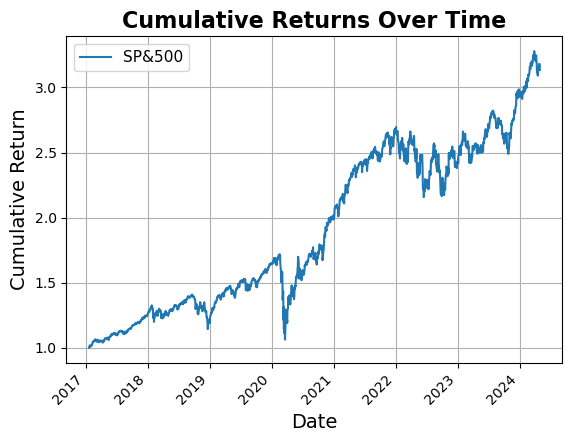

The CAGR is: 16.91%
Sharpe Ratio of Strategy: 0.89


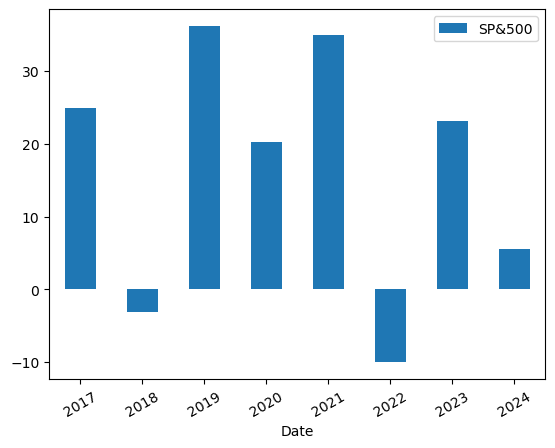

In [13]:
# Compute performance metrics based on the predictions and actual returns.
# - Use the 'func_lib.compute_BM_Perf()' function to calculate cumulative and calendar returns.
# - Pass the DataFrame 'y_test_and_pred' containing the actual and predicted values as an argument.
cum_returns, calendar_returns = func_lib.compute_BM_Perf(y_test_and_pred)

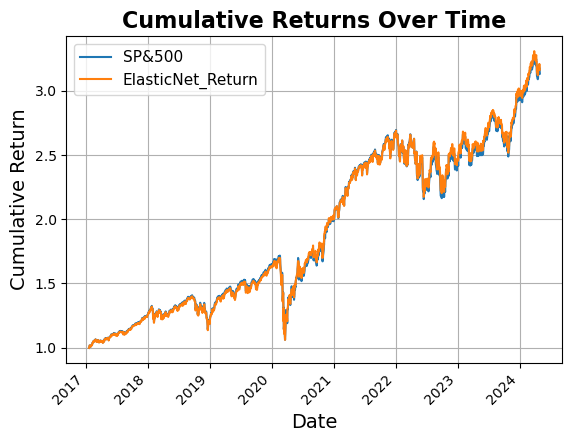

The CAGR is: 17.07%
Sharpe Ratio of Strategy: 0.93


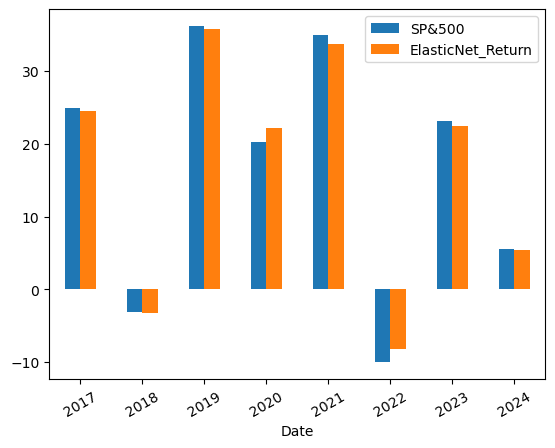

In [14]:
# Compute strategy performance metrics.
# - Use the 'func_lib.compute_strat_perf()' function to calculate the performance of the trading strategy.
# - Pass the following arguments:
#   - 'y_test_and_pred': The DataFrame containing actual and predicted values.
#   - 'cum_returns': Cumulative returns calculated previously.
#   - 'calendar_returns': Calendar returns calculated previously.
#   - 'trading_strategy': The function defining the trading strategy based on predictions.
#   - 'model_name': The name of the model to include in the performance evaluation.
cum_returns, calendar_returns = func_lib.compute_strat_perf(
    y_test_and_pred, cum_returns, calendar_returns, trading_strategy, model_name
)